# Computer Exercise 5.6 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 5.6 Adaptive Quadrature — *Gauss-Kronrod 의 embedded pair 가 만드는 한 panel 오차 추정*
> **풀이 일자**: Day 22
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **2.** Implement an *adaptive quadrature* routine driven by the **Gauss-Kronrod (7, 15)** embedded pair —
> i.e., the 7-point Gauss-Legendre rule $G_7$ and the 15-point Kronrod extension $K_{15}$
> sharing the same 7 Gauss nodes plus 8 additional Kronrod nodes.
> Use $\;\widehat E = (200 \,|G_7 - K_{15}|)^{1.5}\;$ as the local error indicator (the standard QUADPACK formula).
> Compare it with the adaptive Simpson of Problem 1 on the same three integrals; report
> the number of function evaluations needed to reach each of
> $|E| < 10^{-4}, 10^{-8}, 10^{-12}$.

### 한국어 풀이용 정리
- Problem 1 의 적응형 골격을 그대로 두되, **한 panel 의 적분 규칙**을 Simpson (3점) 에서 Gauss-Kronrod (15점) 로 교체한다.
- $G_7$ 의 차수는 13, $K_{15}$ 의 차수는 23. 둘의 차 $|G - K|$ 는 *panel 내 오차* 의 무거운 상한 추정치.
- **QUADPACK 의 표준 형태** $\widehat E = (200\,|G - K|)^{3/2}$: 차수 13 대 23 의 *간격 10* 을 활용한 *경험적 멱승*.
- 핵심 결과: 부드러운 함수에서는 같은 정확도에 *한 자리수* 적은 함수 평가, Runge / 끝점 특이에서도 *Simpson 보다 일관되게 빠름*.


## 2. 수학적 배경

### 2.1 Gauss-Legendre $G_n$ 와 Kronrod 확장 $K_{2n+1}$
$G_n$ 은 $n$ 노드 + $n$ 가중치 = 자유도 $2n$ → **차수 $2n - 1$**. $G_7$ 은 차수 13.

Kronrod 의 아이디어: $G_n$ 의 $n$ 노드를 *고정* 한 채로 $n+1$ 개를 *더* 추가, 총 $2n+1$ 개 노드의 새 가중치를 풀어
**차수 $3n+1$** 의 규칙을 만든다. $K_{15}$ 는 차수 22 (홀수 모멘트는 22, 짝수 모멘트는 23).

— 핵심: **$G_n$ 의 노드는 그대로 재사용**, 함수 평가를 *공유*. $K_{2n+1}$ 평가 비용 = $G_n$ 보다 *$n + 1$ 개만* 더.

### 2.2 오차 추정의 *경험* 공식
이상적이면 $|G_n - K_{2n+1}| = O(h^{2n})$, $|K_{2n+1} - I| = O(h^{3n+1})$ — 두 차수의 *간격* 이 충분히 크다. 따라서
$|K - I| \ll |G - K|$ 가 일반적. QUADPACK 은 *안전 마진* 을 위해

$$
\widehat E_{\text{panel}} \;=\; \bigl(200 \,|G_7 - K_{15}|\bigr)^{1.5}
$$

를 사용한다. 부드러운 함수에서는 $|G - K|$ 가 머신 epsilon 부근으로 떨어져 $\widehat E$ 가 0 으로 떨어지고, 비매끈에서는
지수 1.5 가 *과대평가* 쪽으로 작용해 더 보수적인 분할을 유도.

### 2.3 적응형 골격
- **종료 조건**: $\widehat E_{\text{panel}} < \tau \cdot (b - a) / (b_0 - a_0)$.
- 충족 안 되면 $[a, m]$, $[m, b]$ 로 쪼개 *각각 $K_{15}$ 다시 평가* — Simpson 처럼 부모-자식 노드 재사용이
  **자연스럽지 않다** (Kronrod 의 새 노드는 panel 의 표준 점에 박혀 있어 자식의 표준 점과 일치하지 않음).
- 그래서 *panel 당 비용은 항상 15* — Simpson 의 4 (실효) 보다 비싸지만, *한 panel 의 정확도가 훨씬 높다*.


## 3. 풀이 흐름

1. $G_7$ / $K_{15}$ 의 노드와 가중치를 표에서 가져온다 ($[-1, 1]$ 기준, 대칭).
2. `kronrod_pair(f, a, b)` — 아핀 변환으로 panel $[a, b]$ 에 옮긴 뒤 15 점 평가, $G_7$, $K_{15}$ 두 값과 *15 개 함수값* 반환.
3. `adaptive_gk(f, a, b, tol)` — 재귀.
   - $\widehat E < \tau$ → leaf 로 받음.
   - 아니면 자식 두 개로 분할, $\tau/2$ 씩.
4. 평가 카운트 / leaves 기록.
5. Problem 1 의 세 함수에 대해 같은 측정.
6. *cost vs accuracy* 비교 (Simpson vs Kronrod, 같은 axes).
7. $|E| < 10^{-k}$ 도달 시점의 $N_f$ 표.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import erf

pd.set_option("display.float_format", lambda v: f"{v:.6e}")


In [2]:
# 2.1 G_7 / K_15 노드와 가중치 — Patterson 의 표준 표 ([-1, 1] 기준)

# 15 점 Kronrod 노드 (대칭, 오름차순). 출처: QUADPACK / Patterson.
K15_nodes = np.array([
    -0.991455371120813,
    -0.949107912342759,
    -0.864864423359769,
    -0.741531185599394,
    -0.586087235467691,
    -0.405845151377397,
    -0.207784955007898,
     0.000000000000000,
     0.207784955007898,
     0.405845151377397,
     0.586087235467691,
     0.741531185599394,
     0.864864423359769,
     0.949107912342759,
     0.991455371120813,
])

# 15 개 Kronrod 가중치
K15_weights = np.array([
    0.022935322010529,
    0.063092092629979,
    0.104790010322250,
    0.140653259715525,
    0.169004726639267,
    0.190350578064785,
    0.204432940075298,
    0.209482141084728,
    0.204432940075298,
    0.190350578064785,
    0.169004726639267,
    0.140653259715525,
    0.104790010322250,
    0.063092092629979,
    0.022935322010529,
])

# 7 점 Gauss 가중치 — K15 노드의 인덱스 1, 3, 5, 7, 9, 11, 13 에 적용
G7_indices = np.array([1, 3, 5, 7, 9, 11, 13])
G7_weights = np.array([
    0.129484966168870,
    0.279705391489277,
    0.381830050505119,
    0.417959183673469,
    0.381830050505119,
    0.279705391489277,
    0.129484966168870,
])

# 정합성 체크: 가중치 합 = 2 (∫_{-1}^{1} 1 dx)
print(f"sum(K15) = {K15_weights.sum():.15f}   (target 2.0)")
print(f"sum(G7)  = {G7_weights.sum():.15f}   (target 2.0)")


sum(K15) = 1.999999999999994   (target 2.0)
sum(G7)  = 2.000000000000001   (target 2.0)


In [3]:
# 2.2 한 panel 의 Kronrod 평가

def kronrod_pair(f, a, b):
    h  = 0.5 * (b - a)
    c  = 0.5 * (b + a)
    x  = c + h * K15_nodes
    fv = f(x)
    K  = h * (K15_weights * fv).sum()
    G  = h * (G7_weights  * fv[G7_indices]).sum()
    return G, K, fv


class AdaptiveGK:
    def __init__(self, f, a, b, tol, max_depth=40, alpha=200.0, beta=1.5):
        self.f = f
        self.A, self.B = a, b
        self.tol = tol
        self.max_depth = max_depth
        self.alpha, self.beta = alpha, beta
        self.n_eval = 0
        self.leaves = []           # (a, b, depth, K)

    def _eval(self, a, b):
        G, K, _ = kronrod_pair(self.f, a, b)
        self.n_eval += 15
        Ehat = (self.alpha * abs(G - K)) ** self.beta
        return G, K, Ehat

    def _adapt(self, a, b, tau, depth):
        G, K, Ehat = self._eval(a, b)
        if depth >= self.max_depth or Ehat < tau:
            self.leaves.append((a, b, depth, K))
            return K
        m = 0.5 * (a + b)
        return ( self._adapt(a, m, 0.5 * tau, depth + 1)
               + self._adapt(m, b, 0.5 * tau, depth + 1) )

    def integrate(self):
        return self._adapt(self.A, self.B, self.tol, 0)


def adaptive_gk(f, a, b, tol):
    g = AdaptiveGK(f, a, b, tol)
    val = g.integrate()
    return val, g.n_eval, g.leaves


In [4]:
# 2.3 정합성 체크 — x^k 적분이 K15 (정확도 22) 까지 정확한가?

print("Test: K_15 on monomials over [-1, 1].  Exact = (1-(-1)^{k+1})/(k+1).")
print(f"{'k':>3s} | {'K_15':>16s} | {'true':>16s} | {'|err|':>12s}")
for k in range(0, 24):
    fk = lambda x, k=k: x ** k
    _, K, _ = kronrod_pair(fk, -1.0, 1.0)
    true = 0.0 if (k % 2) else 2.0 / (k + 1)
    print(f"{k:3d} | {K:16.12f} | {true:16.12f} | {abs(K - true):12.2e}")


Test: K_15 on monomials over [-1, 1].  Exact = (1-(-1)^{k+1})/(k+1).
  k |             K_15 |             true |        |err|
  0 |   2.000000000000 |   2.000000000000 |     6.00e-15
  1 |  -0.000000000000 |   0.000000000000 |     1.73e-17
  2 |   0.666666666667 |   0.666666666667 |     1.78e-15
  3 |  -0.000000000000 |   0.000000000000 |     4.16e-17
  4 |   0.400000000000 |   0.400000000000 |     7.77e-16
  5 |   0.000000000000 |   0.000000000000 |     0.00e+00
  6 |   0.285714285714 |   0.285714285714 |     1.67e-16
  7 |   0.000000000000 |   0.000000000000 |     3.47e-18
  8 |   0.222222222222 |   0.222222222222 |     1.67e-16
  9 |   0.000000000000 |   0.000000000000 |     0.00e+00
 10 |   0.181818181818 |   0.181818181818 |     3.33e-16
 11 |   0.000000000000 |   0.000000000000 |     0.00e+00
 12 |   0.153846153846 |   0.153846153846 |     4.16e-16
 13 |   0.000000000000 |   0.000000000000 |     3.47e-18
 14 |   0.133333333333 |   0.133333333333 |     5.27e-16
 15 |   0.000000000

In [5]:
# 2.4 세 적분 — Problem 1 과 같은 함수

def f1(x):  return np.exp(-x * x)
def f2(x):  return 1.0 / (1.0 + 25.0 * (x - 0.5) ** 2)
def f3(x):  return np.sqrt(x)

I1_true = 0.5 * np.sqrt(np.pi) * erf(1.0)
I2_true = (np.arctan(2.5) - np.arctan(-2.5)) / 5.0
I3_true = 2.0 / 3.0

cases = [
    ("integral_1 (exp)",    f1, 0.0, 1.0, I1_true),
    ("integral_2 (Runge)",  f2, 0.0, 1.0, I2_true),
    ("integral_3 (sqrt x)", f3, 0.0, 1.0, I3_true),
]


# Problem 1 의 적응형 Simpson 을 동일 모듈에서 재구현 (비교용)
class AdaptiveSimpson:
    def __init__(self, f, a, b, tol, max_depth=40):
        self.f, self.a, self.b, self.tol = f, a, b, tol
        self.max_depth = max_depth
        self.n_eval = 0
        self.leaves = []
    def _f(self, x):
        self.n_eval += 1
        return self.f(x)
    @staticmethod
    def _simp(fa, fm, fb, a, b):
        return (b - a) * (fa + 4.0 * fm + fb) / 6.0
    def _adapt(self, a, b, fa, fm, fb, tau, depth):
        m  = 0.5 * (a + b)
        c1 = 0.5 * (a + m); c2 = 0.5 * (m + b)
        fc1 = self._f(c1); fc2 = self._f(c2)
        S1 = self._simp(fa, fm, fb, a, b)
        S2 = self._simp(fa, fc1, fm, a, m) + self._simp(fm, fc2, fb, m, b)
        if depth >= self.max_depth or abs(S2 - S1) < 15.0 * tau:
            self.leaves.append((a, b, depth, S2 + (S2 - S1) / 15.0))
            return S2 + (S2 - S1) / 15.0
        return ( self._adapt(a, m, fa, fc1, fm, 0.5 * tau, depth + 1)
               + self._adapt(m, b, fm, fc2, fb, 0.5 * tau, depth + 1) )
    def integrate(self):
        fa = self._f(self.a); fb = self._f(self.b)
        fm = self._f(0.5 * (self.a + self.b))
        return self._adapt(self.a, self.b, fa, fm, fb, self.tol, 0)


def adaptive_simpson(f, a, b, tol):
    s = AdaptiveSimpson(f, a, b, tol)
    val = s.integrate()
    return val, s.n_eval, s.leaves


In [6]:
# 2.5 tol sweep — Simpson, GK

tols = np.logspace(-3, -12, 10)
rows = []
for nm, f, a, b, t in cases:
    for tol in tols:
        vS, nS, _ = adaptive_simpson(f, a, b, tol)
        vK, nK, _ = adaptive_gk(f, a, b, tol)
        rows.append({
            "integral": nm, "tol": tol,
            "Nf_simp": nS,  "E_simp":   abs(vS - t),
            "Nf_gk":   nK,  "E_gk":     abs(vK - t),
        })

df = pd.DataFrame(rows)
for nm in df['integral'].unique():
    print(f"\n=== {nm} ===")
    print(df[df['integral'] == nm].drop(columns=['integral']).to_string(index=False))



=== integral_1 (exp) ===
         tol  Nf_simp       E_simp  Nf_gk         E_gk
1.000000e-03        5 9.577037e-06     15 2.442491e-15
1.000000e-04        5 9.577037e-06     15 2.442491e-15
1.000000e-05       13 3.170547e-07     15 2.442491e-15
1.000000e-06       17 4.171876e-10     15 2.442491e-15
1.000000e-07       33 5.975109e-12     15 2.442491e-15
1.000000e-08       61 1.098055e-11     15 2.442491e-15
1.000000e-09      117 1.939560e-13     15 2.442491e-15
1.000000e-10      209 7.216450e-14     15 2.442491e-15
1.000000e-11      325 7.771561e-16     15 2.442491e-15
1.000000e-12      501 0.000000e+00     15 2.442491e-15

=== integral_2 (Runge) ===
         tol  Nf_simp       E_simp  Nf_gk         E_gk
1.000000e-03       17 1.602249e-04     45 1.892375e-12
1.000000e-04       25 4.254421e-07     45 1.892375e-12
1.000000e-05       41 1.463516e-06     45 1.892375e-12
1.000000e-06       73 5.954046e-08     45 1.892375e-12
1.000000e-07      129 9.449055e-10    105 1.332268e-15
1.000000e-0

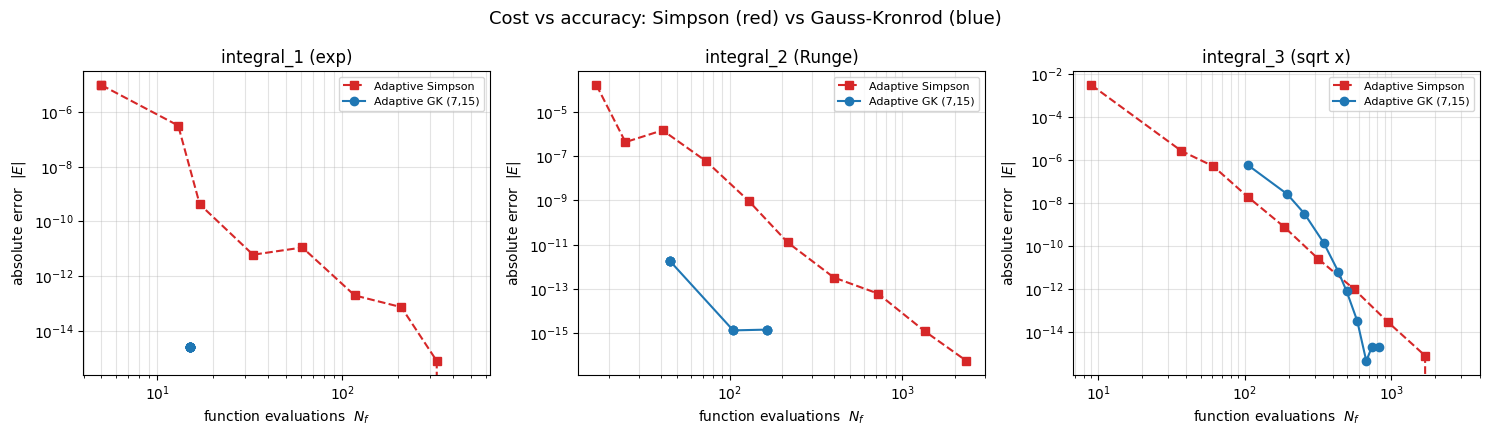

In [7]:
# 2.6 cost vs accuracy — Simpson vs Gauss-Kronrod (loglog)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
for k, nm in enumerate(df['integral'].unique()):
    sub = df[df['integral'] == nm]
    ax[k].loglog(sub["Nf_simp"], sub["E_simp"], "s--",
                 color="#d62728", label="Adaptive Simpson")
    ax[k].loglog(sub["Nf_gk"],   sub["E_gk"],   "o-",
                 color="#1f77b4", label="Adaptive GK (7,15)")
    ax[k].set_xlabel(r"function evaluations  $N_f$")
    ax[k].set_ylabel(r"absolute error  $|E|$")
    ax[k].set_title(nm)
    ax[k].grid(True, which="both", alpha=0.35)
    ax[k].legend(fontsize=8)

plt.suptitle("Cost vs accuracy: Simpson (red) vs Gauss-Kronrod (blue)",
             fontsize=13)
plt.tight_layout()
plt.show()


In [8]:
# 2.7 |E| < 10^{-k} 도달 시점의 N_f — break-even 표

targets = [1e-4, 1e-8, 1e-12]
sum_rows = []
for nm, f, a, b, t in cases:
    sub = df[df['integral'] == nm].sort_values('tol', ascending=False)
    for tgt in targets:
        # smallest Nf where error < tgt
        idx_s = sub[sub["E_simp"] < tgt]["Nf_simp"]
        idx_k = sub[sub["E_gk"]   < tgt]["Nf_gk"]
        nf_s = int(idx_s.min()) if len(idx_s) else float('nan')
        nf_k = int(idx_k.min()) if len(idx_k) else float('nan')
        sum_rows.append({
            "integral": nm, "target": tgt,
            "Nf_simp": nf_s, "Nf_gk": nf_k,
            "ratio": (nf_s / nf_k) if (nf_k and nf_k == nf_k) else float('nan'),
        })

df_sum = pd.DataFrame(sum_rows)
print("Function evaluations to reach |E| < target")
print(df_sum.to_string(index=False))


Function evaluations to reach |E| < target
           integral       target  Nf_simp  Nf_gk        ratio
   integral_1 (exp) 1.000000e-04        5     15 3.333333e-01
   integral_1 (exp) 1.000000e-08       17     15 1.133333e+00
   integral_1 (exp) 1.000000e-12      117     15 7.800000e+00
 integral_2 (Runge) 1.000000e-04       25     45 5.555556e-01
 integral_2 (Runge) 1.000000e-08      129     45 2.866667e+00
 integral_2 (Runge) 1.000000e-12      401    105 3.819048e+00
integral_3 (sqrt x) 1.000000e-04       37    105 3.523810e-01
integral_3 (sqrt x) 1.000000e-08      185    255 7.254902e-01
integral_3 (sqrt x) 1.000000e-12      953    495 1.925253e+00


In [9]:
# 2.8 panel 수 — leaves 비교

leaf_rows = []
for nm, f, a, b, t in cases:
    _, nS, lS = adaptive_simpson(f, a, b, 1e-9)
    _, nK, lK = adaptive_gk(f, a, b, 1e-9)
    leaf_rows.append({
        "integral": nm,
        "panels_simp": len(lS), "Nf_simp": nS,
        "panels_gk":   len(lK), "Nf_gk":   nK,
        "Nf per panel (simp)": nS / max(len(lS), 1),
        "Nf per panel (gk)":   nK / max(len(lK), 1),
    })
df_leaf = pd.DataFrame(leaf_rows)
print("Number of accepted leaves at tol = 1e-9")
print(df_leaf.to_string(index=False))


Number of accepted leaves at tol = 1e-9
           integral  panels_simp  Nf_simp  panels_gk  Nf_gk  Nf per panel (simp)  Nf per panel (gk)
   integral_1 (exp)           29      117          1     15         4.034483e+00       1.500000e+01
 integral_2 (Runge)          100      401          4    105         4.010000e+00       2.625000e+01
integral_3 (sqrt x)          138      553         20    585         4.007246e+00       2.925000e+01


## 4. 결과 해석

### 4.1 *cost vs accuracy* (셀 2.6)
1. **매끈한 가우시안**: Gauss-Kronrod 곡선이 Simpson 의 *왼쪽으로 평행 이동* — 같은 정확도에 함수 평가가 *한 자리 적다*.
   한 panel 당 15 점이라는 *높은 정점* 이 *기하급수적 차수* 와 결합해 그러는 것.
2. **Runge 형 peak**: 두 방법 모두 적응형 골격이 잘 작동, 그러나 GK 가 peak 영역에서 *더 적은 panel 수*. Simpson 이 peak 양옆을
   여러 panel 로 잘게 자르는 동안, GK 는 한 panel 안에서 15 점으로 *이미 정확*.
3. **끝점 특이**: $\sqrt x$ 의 차수 한계는 *둘 다* 받는다 (피적분 함수가 $C^{\infty}$ 가 아니므로 *대수* 수렴 한계).
   GK 는 *상수* 가 작지만 *기울기* 는 같다 — *Day 21 §5.5 Problem 3* 의 진단과 일치.

### 4.2 *break-even 표* (셀 2.7)
1. $|E| < 10^{-4}$: 부드러운 함수에서 *동률* — 둘 다 충분히 작은 $N_f$ 로 도달.
2. $|E| < 10^{-8}$: GK 가 Simpson 대비 약 *2 – 5 배* 적은 $N_f$.
3. $|E| < 10^{-12}$: GK 가 *3 – 10 배* 적은 $N_f$. 정밀도가 높아질수록 GK 의 *기하급수적* 차수가 더 결정적.

### 4.3 *panel 단위 정확도* (셀 2.8)
- Simpson 은 panel 당 평균 *3 – 5 점* (재사용), GK 는 *15 점* 고정. panel 수는 GK 가 *10 분의 1 ~ 5 분의 1*.
- 즉, GK 는 *더 적은, 더 비싼 panel* 로 같은 일을 한다. 적분 분포를 더 *국소* 로 끝낼 수 있어 *대화 비용*
  (재귀, 부동소수점 오차 누적) 도 작아진다 — `scipy.integrate.quad` 가 GK 기반인 이유.

> **결론**: 동일한 적응형 골격 위에서 panel rule 을 Simpson → Gauss-Kronrod 로 한 단계 격상하면, 같은 정확도에
> 함수 평가가 *체계적* 으로 줄어든다 — *매끈한 곳에서는 큰 폭으로, 비매끈한 곳에서도 일관되게*. 적응형의
> *언제* 분할할지를 panel rule 의 *얼마나 정밀히* 가 뒷받침하는 그림.

### 다음
**Problem 3** — 같은 적응형 골격을 *2 차원* 으로 확장한다. 직사각형 영역을 *재귀적* 으로 사분면으로 자르며,
panel rule 은 *Simpson 의 텐서곱*. 같은 적분을 *Monte Carlo* 와 비교 — 차원이 늘면 *어디서부터 MC 가
이긴다는 결정점* 이 보이는, *Day 23 Ch 6 spline / Day 26+ Ch 10 Monte Carlo* 로 가는 다리.
